Matrix size (n): 1000
True rank: 5
Observation probability (p): 0.2
Noise std (sigma): 0.0001
Using fixed lambda: 7.071068e-02
Iter    1 | rel_inf_err = 9.999195e-01 | abs_inf_err = 1.673066e+01 | lambda = 7.071068e-02 | rel_change = 1.012e+15
Iter   10 | rel_inf_err = 9.984120e-01 | abs_inf_err = 1.670544e+01 | lambda = 7.071068e-02 | rel_change = 3.865e-03
Iter   20 | rel_inf_err = 9.949169e-01 | abs_inf_err = 1.664696e+01 | lambda = 7.071068e-02 | rel_change = 6.349e-03
Iter   30 | rel_inf_err = 9.899412e-01 | abs_inf_err = 1.656370e+01 | lambda = 7.071068e-02 | rel_change = 8.105e-03
Iter   40 | rel_inf_err = 9.838646e-01 | abs_inf_err = 1.646203e+01 | lambda = 7.071068e-02 | rel_change = 9.271e-03
Iter   50 | rel_inf_err = 9.765288e-01 | abs_inf_err = 1.633929e+01 | lambda = 7.071068e-02 | rel_change = 1.002e-02
Iter   60 | rel_inf_err = 9.682779e-01 | abs_inf_err = 1.620123e+01 | lambda = 7.071068e-02 | rel_change = 1.046e-02
Iter   70 | rel_inf_err = 9.600251e-01 | abs_inf_err =

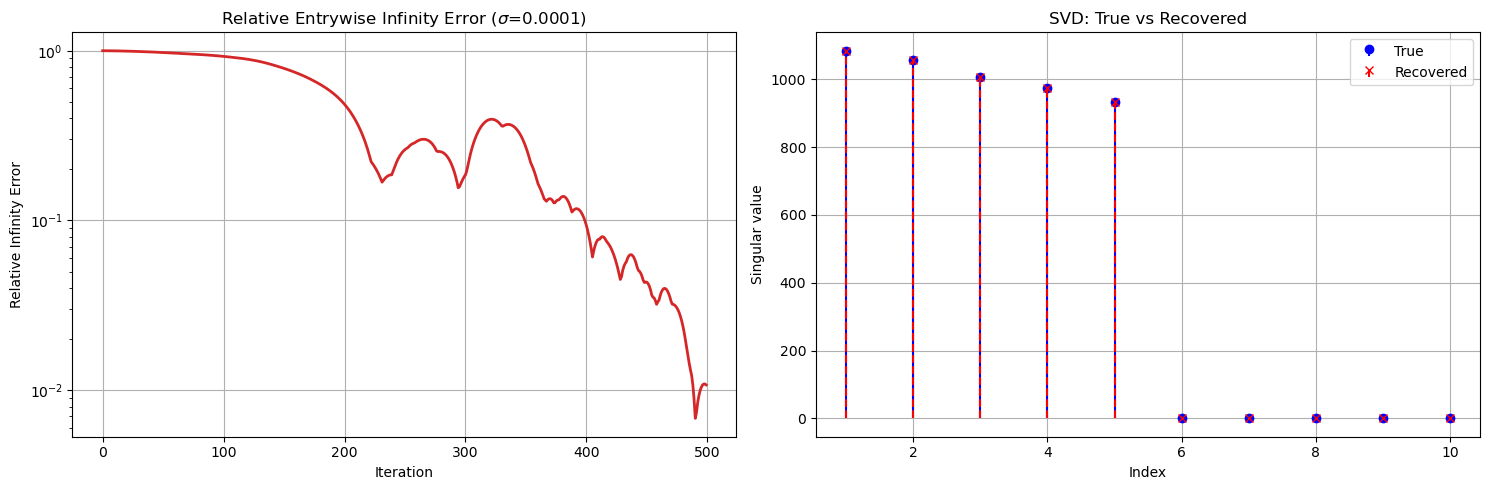


Final evaluation:
Final absolute infinity error      = 1.797832e-01
Final relative infinity error      = 1.074487e-02
True nuclear norm                 = 5.057707e+03
Recovered nuclear norm            = 5.056952e+03
True Rank: 5
Recovered Rank (loose, 1e-3)      = 5
Recovered Rank (strict, 5e-2)     = 5

Unobserved-entry reconstruction evaluation:
Absolute infinity error on missing entries = 1.797832e-01
Relative infinity error on missing entries = 1.074487e-02
RMSE on missing entries                    = 2.490506e-03


In [2]:
import numpy as np
import matplotlib.pyplot as plt


def generate_noisy_data(n, rank, observation_ratio, noise_std, seed=42):
    rng = np.random.default_rng(seed)

    # True low-rank matrix
    U = rng.standard_normal((n, rank))
    V = rng.standard_normal((n, rank))
    M_true = U @ V.T

    # Add Gaussian noise
    noise = rng.normal(0.0, noise_std, size=(n, n))
    M_noisy = M_true + noise

    # Observation mask
    mask = (rng.random((n, n)) < observation_ratio).astype(float)
    M_obs = M_noisy * mask

    return M_true, M_obs, mask


def singular_value_thresholding(Y, tau):
    U, S, Vh = np.linalg.svd(Y, full_matrices=False)
    S_thresh = np.maximum(S - tau, 0.0)
    return U @ np.diag(S_thresh) @ Vh


def absolute_entrywise_infinity_error(Z_hat, Z_true):
    return np.max(np.abs(Z_hat - Z_true))


def relative_entrywise_infinity_error(Z_hat, Z_true, eps=1e-12):
    return np.max(np.abs(Z_hat - Z_true)) / (np.max(np.abs(Z_true)) + eps)


def nuclear_norm(Z):
    return np.sum(np.linalg.svd(Z, compute_uv=False))


def unobserved_entry_errors(Z_hat, Z_true, mask, eps=1e-12):
    """
    Evaluate reconstruction only on the missing entries.
    """
    missing_mask = 1.0 - mask
    num_missing = int(np.sum(missing_mask))

    if num_missing == 0:
        return {
            "abs_inf_err_missing": 0.0,
            "rel_inf_err_missing": 0.0,
            "rmse_missing": 0.0,
        }

    diff = missing_mask * (Z_hat - Z_true)
    true_missing = missing_mask * Z_true

    abs_inf_err_missing = np.max(np.abs(diff))
    rel_inf_err_missing = abs_inf_err_missing / (np.max(np.abs(true_missing)) + eps)
    rmse_missing = np.sqrt(np.sum(diff**2) / num_missing)

    return {
        "abs_inf_err_missing": abs_inf_err_missing,
        "rel_inf_err_missing": rel_inf_err_missing,
        "rmse_missing": rmse_missing,
    }


def practical_rank_from_singular_values(s, rel_thresh=1e-3):
    if len(s) == 0 or s[0] <= 1e-15:
        return 0
    return int(np.sum(s > rel_thresh * s[0]))


def fista_matrix_completion_fixed_lambda(
    M_obs,
    mask,
    M_true,
    lambda_val,
    max_iter=400,
    tol=1e-6,
    min_iter_before_stop=20,
    verbose=True
):
    """
    Solve:
        min_Z  0.5 ||P_Omega(Z - M_obs)||_F^2 + lambda ||Z||_*
    with fixed lambda and standard FISTA.

    Notes:
    - The optimization itself does NOT use M_true.
    - M_true is used only for evaluation/monitoring in simulation.
    """
    n = M_obs.shape[0]

    Z = np.zeros((n, n))
    Y = np.zeros((n, n))
    t = 1.0

    stats = {
        "abs_inf_error": [],
        "rel_inf_error": [],
        "rel_change": [],
    }

    for k in range(max_iter):
        Z_old = Z.copy()

        # Gradient of smooth part at Y
        grad = mask * (Y - M_obs)

        # Step size = Lipschitz constant = 1
        X = Y - grad

        # Proximal step with fixed lambda
        Z = singular_value_thresholding(X, lambda_val)

        # FISTA momentum
        t_new = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * t * t))
        Y = Z + ((t - 1.0) / t_new) * (Z - Z_old)
        t = t_new

        abs_inf_err = absolute_entrywise_infinity_error(Z, M_true)
        rel_inf_err = relative_entrywise_infinity_error(Z, M_true)
        rel_change = np.linalg.norm(Z - Z_old, 'fro') / (np.linalg.norm(Z_old, 'fro') + 1e-12)

        stats["abs_inf_error"].append(abs_inf_err)
        stats["rel_inf_error"].append(rel_inf_err)
        stats["rel_change"].append(rel_change)

        if verbose and ((k + 1) % 10 == 0 or k == 0):
            print(
                f"Iter {k+1:4d} | rel_inf_err = {rel_inf_err:.6e} | "
                f"abs_inf_err = {abs_inf_err:.6e} | "
                f"lambda = {lambda_val:.6e} | rel_change = {rel_change:.3e}"
            )

        if (k + 1 >= min_iter_before_stop) and (rel_change < tol):
            print(f"Converged at iteration {k+1}")
            break

    return Z, stats


if __name__ == "__main__":
    # Setup
    n = 1000
    rank = 5
    p = 0.2
    sigma = 1e-4

    print(f"Matrix size (n): {n}")
    print(f"True rank: {rank}")
    print(f"Observation probability (p): {p}")
    print(f"Noise std (sigma): {sigma}")

    M_true, M_obs, mask = generate_noisy_data(
        n=n,
        rank=rank,
        observation_ratio=p,
        noise_std=sigma,
        seed=42
    )

    # Fixed theoretical lambda
    lambda_val = 50.0 * sigma * np.sqrt(n * p)
    print(f"Using fixed lambda: {lambda_val:.6e}")

    Z_rec, stats = fista_matrix_completion_fixed_lambda(
        M_obs=M_obs,
        mask=mask,
        M_true=M_true,
        lambda_val=lambda_val,
        max_iter=500,
        tol=1e-6,
        min_iter_before_stop=20,
        verbose=True
    )

    # Final singular values and rank
    s_true = np.linalg.svd(M_true, compute_uv=False)
    s_rec = np.linalg.svd(Z_rec, compute_uv=False)

    recovered_rank_loose = practical_rank_from_singular_values(s_rec, rel_thresh=1e-3)
    recovered_rank_strict = practical_rank_from_singular_values(s_rec, rel_thresh=5e-2)

    # Final nuclear norm comparison
    nuc_true = nuclear_norm(M_true)
    nuc_rec = nuclear_norm(Z_rec)

    # Unobserved-entry reconstruction evaluation
    missing_eval = unobserved_entry_errors(Z_rec, M_true, mask)

    # Plot
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))

    axs[0].plot(stats["rel_inf_error"], color="tab:red", lw=2)
    axs[0].set_title(rf"Relative Entrywise Infinity Error ($\sigma$={sigma})")
    axs[0].set_yscale("log")
    axs[0].set_xlabel("Iteration")
    axs[0].set_ylabel("Relative Infinity Error")
    axs[0].grid(True)

    k = 10
    axs[1].stem(range(1, k + 1), s_true[:k], linefmt='b-', markerfmt='bo', basefmt=' ', label='True')
    axs[1].stem(range(1, k + 1), s_rec[:k], linefmt='r--', markerfmt='rx', basefmt=' ', label='Recovered')
    axs[1].set_title("SVD: True vs Recovered")
    axs[1].set_xlabel("Index")
    axs[1].set_ylabel("Singular value")
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

    print("\nFinal evaluation:")
    print(f"Final absolute infinity error      = {stats['abs_inf_error'][-1]:.6e}")
    print(f"Final relative infinity error      = {stats['rel_inf_error'][-1]:.6e}")
    print(f"True nuclear norm                 = {nuc_true:.6e}")
    print(f"Recovered nuclear norm            = {nuc_rec:.6e}")
    print(f"True Rank: {rank}")
    print(f"Recovered Rank (loose, 1e-3)      = {recovered_rank_loose}")
    print(f"Recovered Rank (strict, 5e-2)     = {recovered_rank_strict}")

    print("\nUnobserved-entry reconstruction evaluation:")
    print(f"Absolute infinity error on missing entries = {missing_eval['abs_inf_err_missing']:.6e}")
    print(f"Relative infinity error on missing entries = {missing_eval['rel_inf_err_missing']:.6e}")
    print(f"RMSE on missing entries                    = {missing_eval['rmse_missing']:.6e}")